# Visualise all the locations

In [2]:
import pickle

import os
import json
import pickle

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from networks import PrimalNetEndToEnd  # make sure this is importable
# from gep_config_parser import parse_config  # only if you really need it

from gep_config_parser import parse_config

In [3]:
CONFIG_FILE_NAME = "config.toml"
data_path = f"experiment-output/ch5/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
data = pickle.load(open(data_path, 'rb'))

input_data = parse_config(CONFIG_FILE_NAME) # Reads the input data using config.toml's experiment.inputs.data path.

gep_ed_data = input_data["experiment"]["experiments"][0]

In [4]:
print(gep_ed_data.keys())

In [5]:
print(f"All the locations:")
print(gep_ed_data["nodes"])
print(f"Lines between locations:")
print(gep_ed_data["transmission_lines"])

In [11]:
# print(gep_ed_data["genenodesrators"]) 
# Get the one with (NED,*)
# Filter the list for tuples starting with 'NED'


In [12]:
import networkx as nx
import matplotlib.pyplot as plt

# Your data
nodes = gep_ed_data["nodes"]
edges = gep_ed_data["transmission_lines"]

# Build graph
G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Layout
pos = nx.spring_layout(G, seed=42)  # reproducible

# Plot
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightblue")
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("European Transmission Network (Abstract Layout)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [19]:
!pwd

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_subgraph(
    nodes,
    edges,
    selected_nodes,
    layout_seed=42,
    figsize=(6, 4),
    node_size=800,
    node_color="lightblue",
    edge_width=2.0,
):
    """
    Plot only selected nodes and edges between them.

    nodes: list of all nodes
    edges: list of (u, v) edges
    selected_nodes: list or set of nodes to plot
    """

    # Build full graph
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # Induced subgraph
    SG = G.subgraph(selected_nodes).copy()

    # Layout on subgraph only
    pos = nx.spring_layout(SG, seed=layout_seed)

    # Plot
    plt.figure(figsize=figsize)
    nx.draw_networkx_nodes(SG, pos, node_size=node_size, node_color=node_color)
    nx.draw_networkx_edges(SG, pos, width=edge_width)
    nx.draw_networkx_labels(SG, pos, font_size=10)

    plt.title(f"Subgraph ({len(SG.nodes)} nodes)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [17]:
selected = ["GER", "FRA", "NED", "BEL","SPA","SWI"]
plot_subgraph(nodes, edges, selected)



## Select a 4th country

To join original experiment with:
- BEL
- GER
- FRA

In [18]:
ned_generators = [gen for gen in gep_ed_data["generators"] if gen[0] == 'SWI']
print("Generators in SWI:")
print(ned_generators)
print(f"Lines with SWI:")
swiss_lines = [line for line in gep_ed_data["transmission_lines"] if 'SWI' in line]
print(swiss_lines)

In [48]:
def plot_data_topology(data_path, name):
    data = pickle.load(open(data_path, 'rb'))
    print(data.N)
    print(data.L)

    # Build graph
    nodes = data.N
    edges = data.L
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    # Layout
    pos = nx.spring_layout(G, seed=42)  # reproducible

    # Plot
    plt.figure(figsize=(6, 4))
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color="lightblue")
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.7)
    nx.draw_networkx_labels(G, pos, font_size=10)

    plt.title("European Transmission Network 4 Node")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [49]:
plot_data_topology(data_path = "data/ED_data/ED_NB-G-F-S_GB2-G2-F2-S2_L5_c0_s0_p0_smp15.pkl", name="Transmission Network Topology")

In [50]:
plot_data_topology(data_path = "data/ED_data/ED_NB-G-F-S_GB2-G2-F2-S2_L4_c0_s0_p0_smp15.pkl", name="Transmission Network Topology")

### Evaluate DataSet Optimal Solution

['BEL', 'GER', 'FRA']


In [161]:
const_data_path = "data/ED_data/Constraint/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse.pkl"
const_data = pickle.load(open(const_data_path, 'rb')) 

In [162]:
''' 
Y value contains
[p, f, md]
Compute the unmet demand contribution + generation contribution of total cost
'''
print(f"Num Loc: {len(const_data.N)}, Num Gen: {len(const_data.G)}, Num Lines: {len(const_data.L)}")
print(f"Y shape: {const_data.opt_targets['y_operational'].shape}")
const_Y = const_data.opt_targets['y_operational']
const_X = const_data.X
print(f"X shape: {const_X.shape} Y shape: {const_Y.shape}")


Num Loc: 3, Num Gen: 6, Num Lines: 3
Y shape: torch.Size([32768, 12])
X shape: torch.Size([32768, 9]) Y shape: torch.Size([32768, 12])


In [163]:
def obj_compute(data, X, Y):
    p_gt, f_lt, md_nt = data.split_dec_vars_from_Y(Y)

    p_gt = torch.abs(p_gt)
    
    cost = data.cost_vec @ p_gt.T

    load_shedding = data.pVOLL * torch.norm(md_nt, p=1, dim=1)

    return  cost, load_shedding, cost + load_shedding


In [288]:
prod_cost, unmet_cost, const_obj = obj_compute(const_data, const_X, const_Y)
percentage_unmet = (unmet_cost / const_obj) * 100
print(f"For the Constraint Dataset")
print("Mean % unmet:", percentage_unmet.mean().item())
print("Median % unmet:", percentage_unmet.median().item())
print("P90 % unmet:", percentage_unmet.quantile(0.9).item())
print(percentage_unmet)

For the Constraint Dataset
Mean % unmet: 58.182367262544346
Median % unmet: 97.06745483672769
P90 % unmet: 99.78967357147681
tensor([99.6659, 88.1942,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
       dtype=torch.float64)


In [290]:
const_renew_data_path = "data/ED_data/Constraint/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbFalse_renewMaxInvFalse.pkl"
const_renew_data = pickle.load(open(const_renew_data_path, 'rb'))
const_renew_X = const_renew_data.X
const_renew_Y = const_renew_data.opt_targets['y_operational']
prod_cost, unmet_cost, const_obj = obj_compute(const_renew_data, const_renew_X, const_renew_Y)
percentage_unmet = (unmet_cost / const_obj) * 100
print(f"For the Renewable Constraint Dataset")
print("Mean % unmet:", percentage_unmet.mean().item())
print("Median % unmet:", percentage_unmet.median().item())
print("P90 % unmet:", percentage_unmet.quantile(0.9).item())
print(percentage_unmet)

For the Renewable Constraint Dataset
Mean % unmet: 56.33368428768824
Median % unmet: 96.44227401170106
P90 % unmet: 99.78456528176552
tensor([98.3751, 98.7313,  0.0000,  ..., 98.1092, 98.6680,  0.0000],
       dtype=torch.float64)


### UnConstraint Data (Original Data)

In [166]:
noconst_data_path = f"experiment-output/ch5/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl"
noconst_data = pickle.load(open(noconst_data_path, 'rb')) 

noconst_Y = noconst_data.opt_targets['y_operational']
noconst_X = noconst_data.X

no_prod_cost, no_unmet_cost, no_const_obj = obj_compute(noconst_data, noconst_X, noconst_Y)
# print(f"Objective value: {no_const_obj}")

no_percentage_unmet = (no_unmet_cost / no_const_obj) * 100
print("Mean % unmet:", no_percentage_unmet.mean().item())
print("Median % unmet:", no_percentage_unmet.median().item())
print("P90 % unmet:", no_percentage_unmet.quantile(0.9).item())
print(no_percentage_unmet)

Mean % unmet: 14.722751311154362
Median % unmet: 0.0
P90 % unmet: 98.52645512512487
tensor([0., 0., 0.,  ..., 0., 0., 0.], dtype=torch.float64)


### Constrained LB Data

In [175]:
const_LB_data_path = "data/ED_data/Constraint/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_ui_constraint1000_smp15_GenConst_lbTrue.pkl"
const_LB_data = pickle.load(open(const_LB_data_path, 'rb')) 

const_LB_Y = const_LB_data.opt_targets['y_operational']
const_LB_X = const_LB_data.X

prod_LB_cost, unmet_LB_cost, const_LB_obj = obj_compute(const_LB_data, const_LB_X, const_LB_Y)


percentage_LB_unmet = (unmet_LB_cost / const_LB_obj) * 100
print(f"For the Constraint Dataset")
print("Mean % unmet:", percentage_LB_unmet.mean().item())
print("Median % unmet:", percentage_LB_unmet.median().item())
print("P90 % unmet:", percentage_LB_unmet.quantile(0.9).item())
print(percentage_LB_unmet)

For the Constraint Dataset
Mean % unmet: 11.581208043315566
Median % unmet: 0.0
P90 % unmet: 95.60143633836678
tensor([99.5735,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
       dtype=torch.float64)


Apparently, in the Unconstrained data, the unmet demand represent a much lower percentage of the overall cost, meaning learning to produce is the most improatnt thing for most of the cases.

### Load a Benders investment Data to check

In [314]:
# import ast
# info_csv_path = "outputs/Benders/3Node//experiment_data_sample_duration:120_start_exact:False_exact_refinement:True_run_name:train:0.8_rho:0.5_rhomax:5000_alpha:10_Baseline.csv" 
# benders_df = pd.read_csv(info_csv_path)
# print(benders_df['investments'])
# benders_inv = np.array(benders_df["investments"].apply(ast.literal_eval).tolist(), dtype=float)
# print(benders_inv.shape)   # [num_samples, num_generators]
import glob
import ast  
def load_dist_investment(folder_path):
    # glob all csv files in the folder

    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    inv_list = []
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        if "investment" in df.columns:
            inv_list.extend(df["investment"].apply(ast.literal_eval).tolist())
    return np.array(inv_list, dtype=float)


exact_benders_path = "outputs/Benders/3Node/iter_logs_inexact_refine_Exact_Solve"
exact_inv = load_dist_investment(folder_path=exact_benders_path)
exact_inv.shape

(5432, 6)

In [315]:
inexact_noLB_renew_path = "outputs/Benders/3Node/iter_logs_inexact_refine_ConstraintRenewablesUBFlex"
inexact_renew_inv = load_dist_investment(folder_path=inexact_noLB_renew_path)
inexact_renew_inv.shape

(8160, 6)

In [316]:
exact_csv_path = "experiment-output/ch7/3nodes/benders_test_data_exact/experiment_data_sample_duration:120_start_exact:True_exact_refinement:False_run_name:train:0.8_rho:0.5_rhomax:5000_alpha:10.csv" 
exact_benders_df = pd.read_csv(exact_csv_path)
opt_investment = np.array(exact_benders_df["investments"].apply(ast.literal_eval).tolist(), dtype=float)
# print(exact_benders_inv.shape)   # [num_samples, num_generators]
# print(exact_benders_df["investments"].shape)

In [317]:
import matplotlib.pyplot as plt
import numpy as np

def plot_generator_histograms(inv, generator_names=None, bins=20, title="Investment distributions"):
    inv = np.asarray(inv, dtype=float)
    num_g = inv.shape[1]

    if generator_names is None:
        generator_names = [f"G{i}" for i in range(num_g)]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for g in range(num_g):
        axes[g].hist(inv[:, g], bins=bins, alpha=0.8)
        axes[g].set_title(str(generator_names[g]))
        axes[g].set_xlabel("Investment")
        axes[g].set_ylabel("Count")
        axes[g].grid(True)

    # hide unused axes if num_g < 6
    for g in range(num_g, len(axes)):
        axes[g].axis("off")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [318]:
# plot_generator_histograms(
#     benders_inv,
#     generator_names=[str(g) for g in const_data.G],
#     bins=20,
#     title="Benders investment distribution per generator"
# )

### Compare differeent Investment Data

In [319]:
constrained_inv = const_data.pUnitInvestment.cpu().numpy()
print(constrained_inv.shape)

constrained_lb_inv = const_LB_data.pUnitInvestment.cpu().numpy()
print(constrained_lb_inv.shape)

unconstrained_inv = noconst_data.pUnitInvestment.cpu().numpy()
print(unconstrained_inv.shape)

(32768, 6)
(32768, 6)
(32768, 6)


In [320]:
import numpy as np
import pandas as pd

def summarize_investment(inv, name="dataset", zero_tol=1e-8):
    inv = np.asarray(inv, dtype=float)

    total_inv = inv.sum(axis=1)
    active_count = (np.abs(inv) > zero_tol).sum(axis=1)

    summary = {
        "dataset": name,
        "num_samples": inv.shape[0],
        "num_generators": inv.shape[1],
        "overall_mean": inv.mean(),
        "overall_median": np.median(inv),
        "overall_min": inv.min(),
        "overall_max": inv.max(),
        "fraction_zero": (np.abs(inv) <= zero_tol).mean(),
        "mean_total_investment": total_inv.mean(),
        "median_total_investment": np.median(total_inv),
        "min_total_investment": total_inv.min(),
        "max_total_investment": total_inv.max(),
        "mean_active_generators": active_count.mean(),
        "median_active_generators": np.median(active_count),
    }
    return pd.Series(summary, name=name)


def summarize_investments_table(investment_sets, zero_tol=1e-8, decimals=2):
    """
    Accepts either:
      - dict: {"benders": benders_inv, "constrained": constrained_inv}
      - list of tuples: [("benders", benders_inv), ("constrained", constrained_inv)]

    Returns:
      DataFrame with metrics as rows and dataset names as columns.
    """
    if isinstance(investment_sets, dict):
        items = investment_sets.items()
    else:
        items = investment_sets

    summaries = []
    for name, inv in items:
        s = summarize_investment(inv, name=name, zero_tol=zero_tol)
        summaries.append(s)

    df = pd.concat(summaries, axis=1)

    # keep text row as text, round numeric rows
    for idx in df.index:
        if idx != "dataset":
            df.loc[idx] = pd.to_numeric(df.loc[idx], errors="coerce").round(decimals)

    return df

In [321]:
table = summarize_investments_table({
    "benders": benders_inv,
    "constrained": constrained_inv,
    "constrained_lb": constrained_lb_inv,
    "unconstrained": unconstrained_inv,
})

table


,benders,constrained,constrained_lb,unconstrained
dataset,benders,constrained,constrained_lb,unconstrained
num_samples,73,32768,32768,32768
num_generators,6,6,6,6
overall_mean,384.28,286.51,527.12,500.0
overall_median,60.0,158.87,529.16,500.0
overall_min,-0.0,0.0,3.56,0.0
overall_max,3975.0,1000.0,999.99,1000.0
fraction_zero,0.22,0.0,0.0,0.0
mean_total_investment,2305.7,1719.06,3162.71,3000.0
median_total_investment,2793.0,1718.96,3164.62,2998.28


In [322]:
print(summarize_investments(constrained_inv, "constrained"))

dataset                     constrained
num_samples                       32768
num_generators                        6
overall_mean                 286.510602
overall_median               158.866158
overall_min                    0.001137
overall_max                  999.995313
fraction_zero                       0.0
mean_total_investment       1719.063609
median_total_investment     1718.957365
min_total_investment         173.033869
max_total_investment        3306.476513
mean_active_generators              6.0
median_active_generators            6.0
dtype: object


In [323]:
import numpy as np
import matplotlib.pyplot as plt

def plot_total_investment_hist(investment_sets, bins=40, title="Total investment per sample"):
    plt.figure(figsize=(9, 6.5))

    for name, inv in investment_sets.items():
        inv = np.asarray(inv, dtype=float)
        total_inv = inv.sum(axis=1)
        plt.hist(total_inv, bins=bins, alpha=0.45, label=name, density=True)

    plt.xlabel("Total investment")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

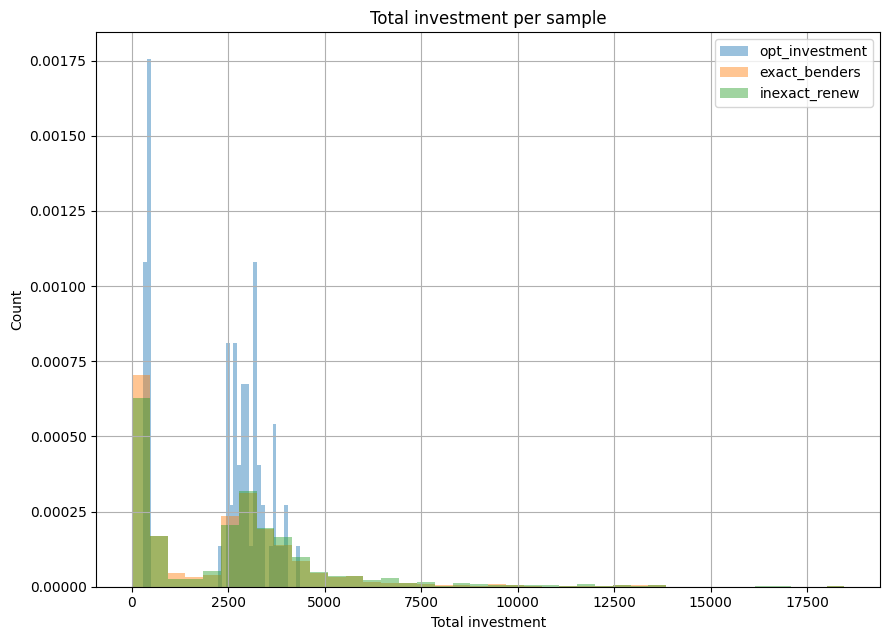

In [324]:
plot_total_investment_hist({
    "opt_investment": opt_investment,

    "exact_benders":exact_inv,
    "inexact_renew": inexact_renew_inv,
    # "constrained": constrained_inv,
    # # "constrained_lb_inv": constrained_lb_inv,
    # "unconstrained": unconstrained_inv,
})

In [325]:
import numpy as np
import matplotlib.pyplot as plt

def plot_individual_investment_hist(
    investment_sets,
    bins=40,
    title="Investment per generator",
    layout=(2, 3),
    percentile_clip=(1, 99),
    density=False
):
    first_inv = np.asarray(next(iter(investment_sets.values())), dtype=float)
    n_generators = first_inv.shape[1]

    nrows, ncols = layout
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    for g in range(n_generators):
        ax = axes[g // ncols, g % ncols]

        # gather all methods for this generator to compute common plotting range
        all_vals = []
        for inv in investment_sets.values():
            inv = np.asarray(inv, dtype=float)
            all_vals.append(inv[:, g])
        all_vals = np.concatenate(all_vals)

        lo, hi = np.percentile(all_vals, percentile_clip)

        for name, inv in investment_sets.items():
            inv = np.asarray(inv, dtype=float)
            vals = inv[:, g]
            ax.hist(vals, bins=bins, range=(lo, hi), alpha=0.45, label=name, density=density)

        ax.set_title(f"Generator {g+1}")
        ax.set_xlabel("Investment")
        ax.set_ylabel("Density" if density else "Count")
        ax.grid(True)

    for k in range(n_generators, nrows * ncols):
        axes[k // ncols, k % ncols].axis("off")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 0.98))
    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

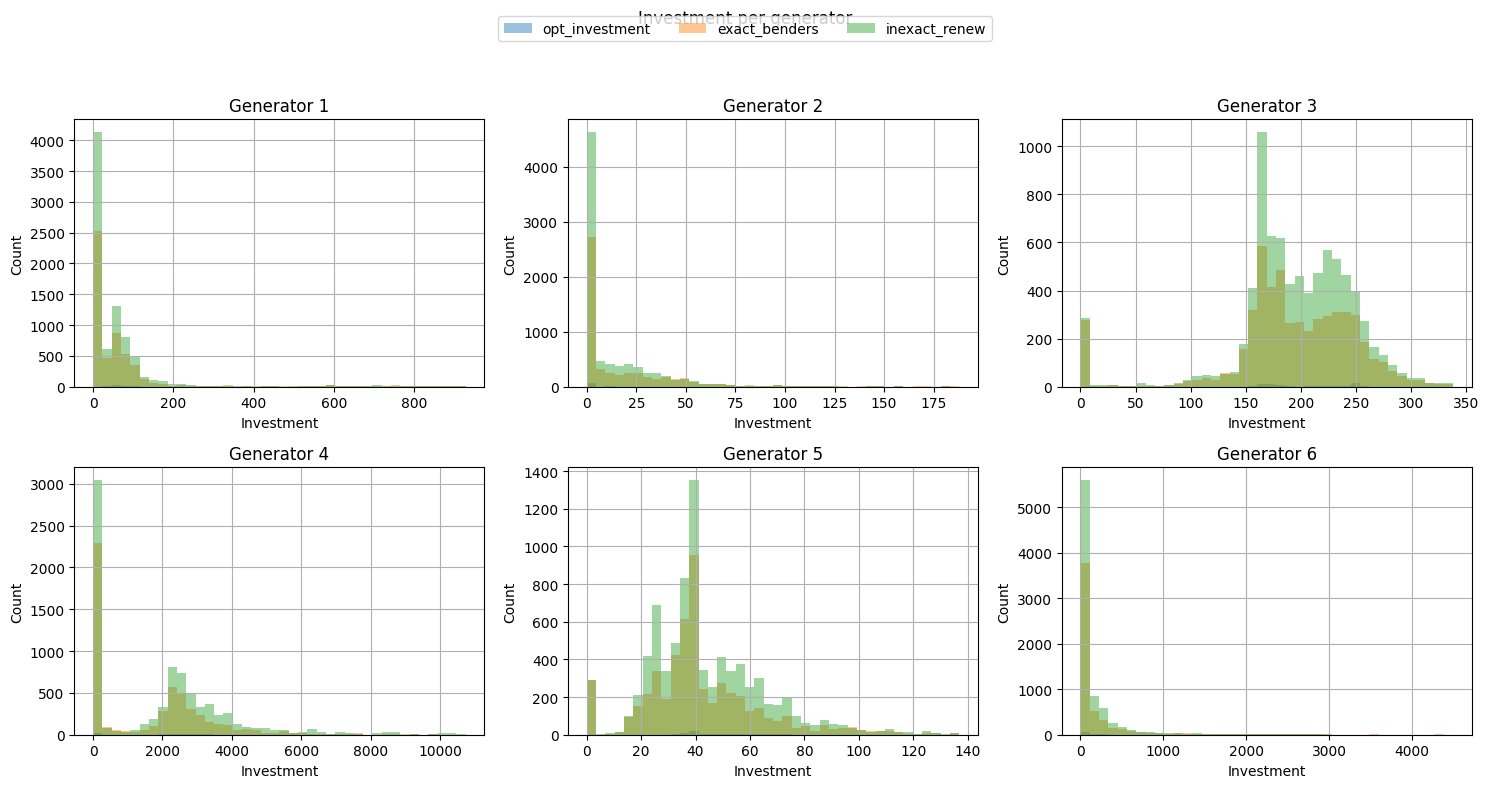

In [326]:
plot_individual_investment_hist({
    "opt_investment": opt_investment,
    "exact_benders": exact_inv,
    "inexact_renew": inexact_renew_inv,
}, bins=40, layout=(2, 3))

In [156]:
import numpy as np
import matplotlib.pyplot as plt

def plot_generator_box_compare(
    investment_sets,
    generator_names=None,
    showfliers=True,
):
    first_inv = next(iter(investment_sets.values()))
    num_g = np.asarray(first_inv, dtype=float).shape[1]

    if generator_names is None:
        generator_names = [f"G{i}" for i in range(num_g)]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for g in range(num_g):
        data_list = []
        labels = []

        for name, inv in investment_sets.items():
            inv = np.asarray(inv, dtype=float)
            data_list.append(inv[:, g])
            labels.append(name)

        axes[g].boxplot(
            data_list,
            labels=labels,
            showfliers=showfliers,
            patch_artist=True,
        )

        # optional colors
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
        for patch, color in zip(axes[g].artists, colors[:len(data_list)]):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)

        axes[g].set_title(str(generator_names[g]))
        axes[g].tick_params(axis="x", rotation=20)
        axes[g].set_ylabel("Investment")
        axes[g].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_15987/2473920744.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[g].boxplot(
/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_15987/2473920744.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[g].boxplot(
/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_15987/2473920744.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[g].boxplot(
/var/folders/3n/3c918lz14kd61yk6hgz4s1x40000gn/T/ipykernel_15987/2473920744.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

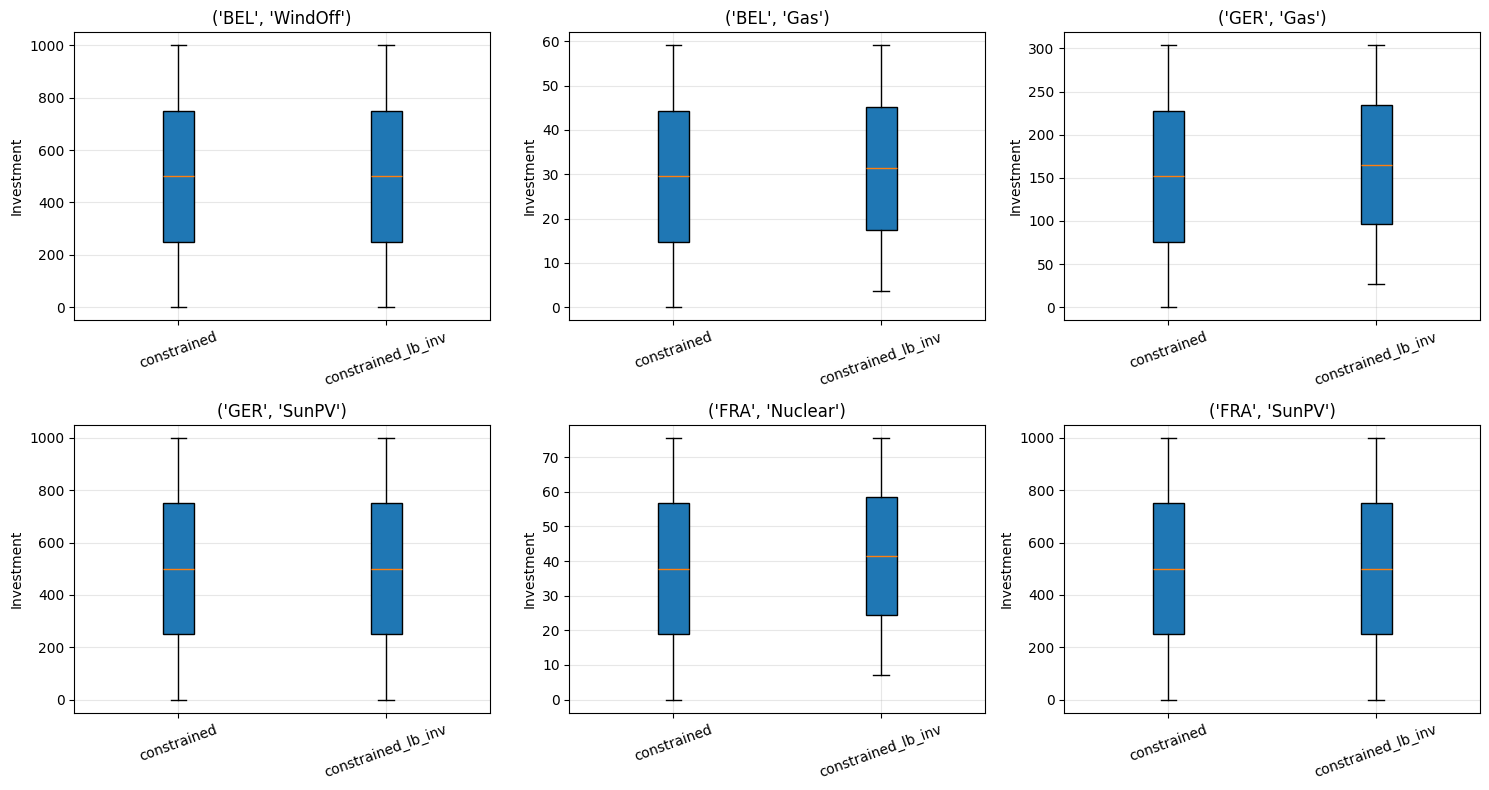

In [159]:
plot_generator_box_compare(
    {
        "constrained": constrained_inv,
        "constrained_lb_inv": constrained_lb_inv,
        # "unconstrained": unconstrained_inv,
    },
    generator_names=[str(g) for g in const_data.G],
    showfliers=False,
)

## Look at proper bound for rewnewables

In [262]:
noconst_data.T

range(1, 8761)

In [264]:
import torch

def renewable_availability_tensor(data, renewable_types=("WindOff", "SunPV","WindOn"), default_ava=1.0):
    """
    data.G: list like [(loc, tech), ...]
    data.T: iterable of timesteps (e.g., range or list)
    data.pGenAva: dict keyed by (loc, tech, t) -> availability in [0,1]

    Returns:
      ava_tensor: torch.Tensor shape [N_renew, T]
      renew_gens: list of (loc, tech) matching rows
      T_list: list of timesteps matching columns
    """
    # Collect renewable generators (preserve order)
    renew_gens = [(loc, tech) for (loc, tech) in data.G if tech in set(renewable_types)]
    T_list = list(data.T)

    N = len(renew_gens)
    Tn = len(T_list)

    ava = torch.empty((N, Tn), dtype=torch.float64)

    for i, (loc, tech) in enumerate(renew_gens):
        for j, t in enumerate(T_list):
            ava[i, j] = float(data.pGenAva.get((loc, tech, t), default_ava))

    return ava, renew_gens, T_list

In [265]:
ava_tensor, renew_gens, T_list = renewable_availability_tensor(noconst_data)
print(ava_tensor.shape)   # (N_renew, T)
print(renew_gens)         # row labels

torch.Size([3, 8760])
[('BEL', 'WindOff'), ('GER', 'SunPV'), ('FRA', 'SunPV')]


In [266]:
print("min/mean/max:", ava_tensor.min().item(), ava_tensor.mean().item(), ava_tensor.max().item())
for i, g in enumerate(renew_gens):
    print(g, "mean ava:", ava_tensor[i].mean().item())

min/mean/max: 0.0 0.26977773972602737 0.991
('BEL', 'WindOff') mean ava: 0.540528196347032
('GER', 'SunPV') mean ava: 0.12262020547945209
('FRA', 'SunPV') mean ava: 0.14618481735159816


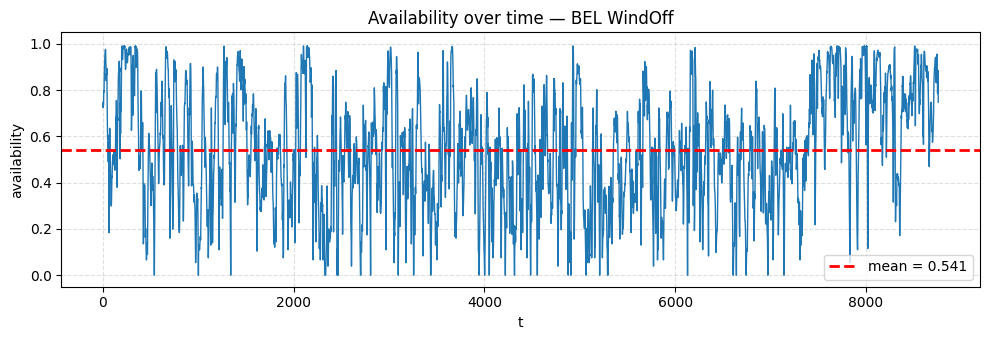

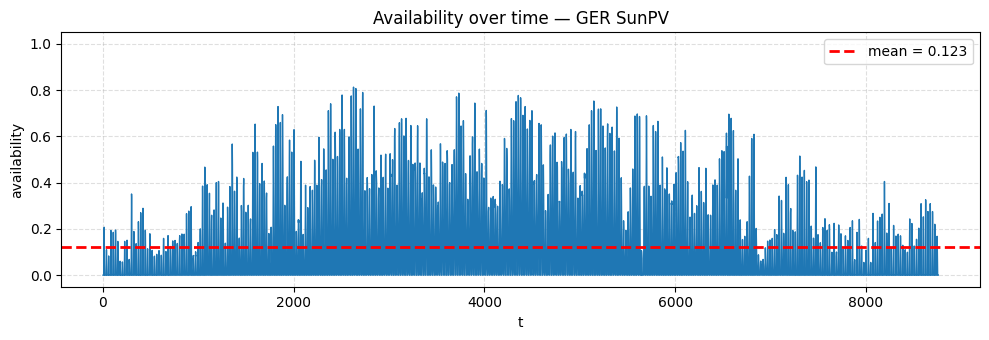

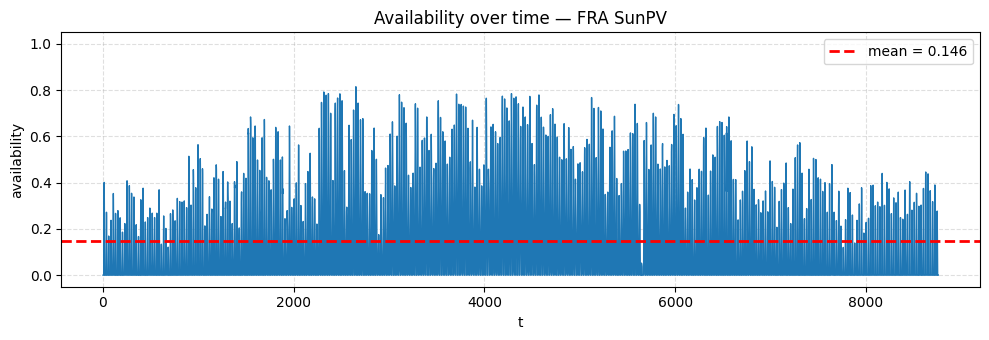

In [268]:

def plot_renewable_availability_series(ava_tensor, renew_gens, T_list=None):
    """
    ava_tensor: torch.Tensor or np.ndarray, shape [N_renew, T]
    renew_gens: list of (loc, tech) length N_renew
    T_list: optional list of timesteps length T (e.g. 1..8760). If None, uses 0..T-1.
    """
    if hasattr(ava_tensor, "detach"):
        A = ava_tensor.detach().cpu().numpy()
    else:
        A = np.asarray(ava_tensor)

    N, T = A.shape
    x = np.array(T_list) if T_list is not None else np.arange(T)

    for i, (loc, tech) in enumerate(renew_gens):
        y = A[i]
        m = float(y.mean())

        plt.figure(figsize=(10, 3.5))
        plt.plot(x, y, linewidth=1)
        plt.axhline(m, linestyle="--", linewidth=2, label=f"mean = {m:.3f}", color="red")
        plt.title(f"Availability over time — {loc} {tech}")
        plt.xlabel("t")
        plt.ylabel("availability")
        plt.ylim(-0.05, 1.05)
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.show()

# use it
plot_renewable_availability_series(ava_tensor, renew_gens, T_list)

In [271]:
for (loc,g) in noconst_data.G:
    cost = noconst_data.pVarCost.get((loc,g), None)
    print(f"Generator {(loc,g)} has variable cost: {cost}")

Generator ('BEL', 'WindOff') has variable cost: 0.005
Generator ('BEL', 'Gas') has variable cost: 0.05
Generator ('GER', 'Gas') has variable cost: 0.05
Generator ('GER', 'SunPV') has variable cost: 0.0001
Generator ('FRA', 'Nuclear') has variable cost: 0.01
Generator ('FRA', 'SunPV') has variable cost: 0.0001


In [273]:
import numpy as np
import torch

def compute_generator_investment_ub(
    data,
    renewable_types=("sunpv", "windon", "windoff"),
    ava_stat="p90",          # "mean", "p90", "max"
    beta=1.05,
    max_inv_cap=None,        # e.g. 1000.0, or None for no global cap
    eps=1e-8,
):
    """
    Returns:
      ub_g: torch.Tensor shape [num_g] with per-generator investment upper bounds u_g^UB
      info: dict with node caps and renewable availability stats (for debugging)
    """

    # 1) node max demand: max_t D_{n,t}
    node_max_demand = {}
    for n in data.N:
        node_max_demand[n] = max(float(data.pDemand[(n, t)]) for t in data.T)

    # 2) node export cap: sum outgoing line export capacities
    node_export_cap = {n: 0.0 for n in data.N}
    for (start_node, end_node) in data.L:
        node_export_cap[start_node] += float(data.pExpCap[(start_node, end_node)])

    # 3) node deliverable cap C_n
    node_cap = {n: node_max_demand[n] + node_export_cap[n] for n in data.N}

    # helper
    def is_renewable(g):
        _, tech = g
        return str(tech).lower() in set(renewable_types)

    def availability_stat(g):
        """Compute A_g^{stat} over time, using pGenAva[(loc, tech, t)]."""
        loc, tech = g
        vals = [float(data.pGenAva.get((loc, tech, t), 1.0)) for t in data.T]
        arr = np.asarray(vals, dtype=float)
        if ava_stat == "mean":
            a = float(arr.mean())
        elif ava_stat == "max":
            a = float(arr.max())
        elif ava_stat == "p90":
            a = float(np.quantile(arr, 0.9))
        elif ava_stat == "constant":
            a = 1.0
        else:
            raise ValueError(f"ava_stat must be one of: mean, p90, max. Got {ava_stat}")
        return max(a, eps)  # avoid division by ~0

    # 4) per-generator ub
    ub = []
    ava_used = {}
    for g in data.G:
        n, _ = g
        pmax = float(data.pUnitCap[g])

        if pmax <= 0:
            u_ub = 0.0
        else:
            Cn = float(node_cap[n])
            if is_renewable(g):
                a = availability_stat(g)
                ava_used[g] = a
                u_ub = beta * Cn / (pmax * a)
            else:
                u_ub = beta * Cn / pmax

        if max_inv_cap is not None:
            u_ub = min(u_ub, float(max_inv_cap))

        ub.append(u_ub)

    ub_g = torch.tensor(ub, dtype=data.DTYPE)

    info = {
        "node_max_demand": node_max_demand,
        "node_export_cap": node_export_cap,
        "node_cap": node_cap,
        "ava_used_for_renewables": ava_used,  # only populated for renewables
    }
    return ub_g, info

In [283]:
ub_g, info = compute_generator_investment_ub(noconst_data, ava_stat = "constant")


for g, ub in zip(noconst_data.G, ub_g.tolist()):
    print(g, "Max Bound in investment generation =", round(ub,2))



('BEL', 'WindOff') Max Bound in investment generation = 147.74
('BEL', 'Gas') Max Bound in investment generation = 59.09
('GER', 'Gas') Max Bound in investment generation = 303.5
('GER', 'SunPV') Max Bound in investment generation = 1517.52
('FRA', 'Nuclear') Max Bound in investment generation = 75.53
('FRA', 'SunPV') Max Bound in investment generation = 1510.56


In [279]:
ub_g, info = compute_generator_investment_ub(noconst_data, ava_stat = "mean")


for g, ub in zip(noconst_data.G, ub_g.tolist()):
    print(g, "u_ub =", ub)

('BEL', 'WindOff') u_ub = 273.3182010531157
('BEL', 'Gas') u_ub = 59.09447769762243
('GER', 'Gas') u_ub = 303.50453688885875
('GER', 'SunPV') u_ub = 12375.796293202193
('FRA', 'Nuclear') u_ub = 75.52820713208159
('FRA', 'SunPV') u_ub = 10333.249170524188


In [286]:
ub_g, info = compute_generator_investment_ub(noconst_data, ava_stat = "p90")


for g, ub in zip(noconst_data.G, ub_g.tolist()):
    print(g, "u_ub =", ub)

('BEL', 'WindOff') u_ub = 165.43806746254882
('BEL', 'Gas') u_ub = 59.09447769762243
('GER', 'Gas') u_ub = 303.50453688885875
('GER', 'SunPV') u_ub = 3613.1492486768902
('FRA', 'Nuclear') u_ub = 75.52820713208159
('FRA', 'SunPV') u_ub = 3180.1350371402773


In [291]:
const_data.pUnitInvestment

tensor([[ 43.2557,  49.5938,  34.6645, 731.2030,  26.5331, 355.2822],
        [ 31.8500,  55.9030, 298.5685, 382.0285,  14.8920, 288.4434],
        [298.2568,  30.3507, 242.0003, 271.8948,  74.1777, 409.6933],
        ...,
        [464.1760,  24.7373, 168.3538,  81.3625,  40.9416, 467.0809],
        [168.0965,  24.2445, 209.4928, 338.9307,  33.8639, 260.0266],
        [297.7216,  25.2453, 133.8877, 946.7477,  36.0149, 928.9264]],
       dtype=torch.float64)